# SD063: Comparison velocities from VMADCP with tidal cycle

## Load required modules

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from VMADCP_section_names import dict_sections
import math
import netCDF4
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import geopandas as gpd
import re
import pandas as pd
from matplotlib.patches import Patch

## User settings

In [55]:
"""Requires either section name as defined in VMADCP_section_names.py"""
section_name = None

"""Or time window (then set section_name to None)"""
# Time window (inclusive). Use ISO strings or leave "" 
# to use the dataset range.
# Examples: "2012-06-02", "2012-06-02 12:00", "2012-06-03T18:30"
start_time = '2026-08-03 10:00:00'
end_time = '2026-08-17 20:00:00'
# end_time = '2026-08-04 20:50:00'
# 'os150nb', 'os150bb' (shallower), 'os75nb' or 'os75bb' (deeper)
adcp = 'os150bb'
# Maximum depth to plot (None = all)
max_depth_plot = 250    # e.g. 500
# depths of timeseries
depth_layers = [30, 90, 150]

lat_min = 68.29
lat_max = 68.295

if section_name is not None:
    start_time = dict_sections[section_name]['start_time']
    end_time = dict_sections[section_name]['end_time']
    adcp = dict_sections[section_name]['adcp']
    max_depth_plot = dict_sections[section_name]['max_depth_plot']
    depth_layers = dict_sections[section_name]['depth_layers']
    

system = 'mac'
if system == 'mac':
    path_server = (
        "/volumes/leg/system/adcp_teledyne_ocean_surveyor/" +
        "acquisition/uhdas/data/SD063_part2/proc/")
elif system == 'windows':
    path_server = ( 
        "system\\adcp_teledyne_ocean_surveyor\\" +
        "acquisition\\uhdas\\data\\SD063_part2\\proc\\")
nc_path = Path(f"/{path_server}{adcp}/contour/{adcp}.nc")

# Load csv file of CTD logsheet
if system == 'mac':
    CTD_file = (
        "/volumes/leg/work/scientific_work_areas/oceanography/" +
        "CTD_deployments_latest.csv")

# Load csv file of tidal amplitude
if system == 'mac':
    tide_file = (
        "/volumes/leg/work/scientific_work_areas/oceanography/" +
        "CTD/Tide_phasefrac_fjordall.csv")

# Greenland coastlines for plotting maps
if system == 'mac':
    boundary_file = (
        "/volumes/leg/work/scientific_work_areas/gis/" +
        "Greenland_coastlines_2017/bas_greenland_coastlines.gpkg")
elif system == 'windows':
    boundary_file = ( 
        "L:\\work\\scientific_work_areas\\gis\\" +
        "Greenland_coastlines_2017\\bas_greenland_coastlines.gpkg")
    
# Save figures
if system == 'mac':
    path_plots = (
        "/volumes/leg/work/scientific_work_areas/oceanography/" +
        "VMADCP/Plots_sections/")
elif system == 'windows':
    boundary_file = ( 
        "L:\\work\\scientific_work_areas\\oceanography\\" +
        "VMADCP\\Plots_sections\\")

save_figs = False
dpi = 300                   # high-DPI PNG
also_save_pdf = False        # vector copy for print

## Load data

In [56]:
ds = xr.open_dataset(nc_path, decode_cf=True)

def clean(da):
    # replace missing value with NaN
    mv = da.attrs.get("missing_value", None)
    if mv is not None:
        da = da.where(da != mv)
    da = da.where(np.abs(da) < 1e37)
    return da

# check if requested variables are in dataset and replace missing
# value with NaN
for v in ["u", "v", "depth", "uship", "vship", "lon", "lat", "pg"]:
    if v not in ds:
        raise KeyError(f"Variable '{v}' not found in dataset")
    ds[v] = clean(ds[v])

# specific cleanup for variable "Percent Good" (pg)
ds['pg'] = ds.pg.where(ds.pg >= 0)

In [57]:
# Load locations of CTDs on this sections to plot on map
df_CTD = pd.read_csv(CTD_file)
df_CTD = df_CTD.rename(
    columns={' CTD cast number(Built In - String)': 'CTD_cast',
             ' Latitude (dd)(sd_gnss_kongsberg_seapath_320_port1_ingga - latitude)': 'lat',
             ' Longitude (dd)(sd_gnss_kongsberg_seapath_320_port1_ingga - longitude)': 'lon',
             ' Event action(Built In - String)': 'action'})
df_CTD["Time"] = pd.to_datetime(df_CTD["Time"], format="%H:%M:%S %d/%m/%Y")
df_CTD = df_CTD[(df_CTD['Time'] >= pd.Timestamp(start_time)) &
    (df_CTD['Time'] <= pd.Timestamp(end_time)) &
    (df_CTD['action'] == 'inWater') & (df_CTD['lat'] >= lat_min) &
    (df_CTD['lat'] <= lat_max)]

In [58]:
# Load tidal amplitude
df_tide = pd.read_csv(tide_file)
df_tide["Time"] = pd.to_datetime(df_tide["Time"], format="%d-%b-%Y %H:%M:%S")
df_tide = df_tide[(df_tide['Time'] >= pd.Timestamp(start_time)) &
    (df_tide['Time'] <= pd.Timestamp(end_time))]
df_tide = df_tide.set_index('Time')
tide_phase = ['high', 'falling', 'low', 'rising']
tide_col = ["palevioletred", "mediumaquamarine", "seagreen", "pink"]

## Select time and region

In [59]:
def parse_time(s):
    return None if (not s or s.strip() == "") else np.datetime64(s)

t0 = parse_time(start_time) or ds.time.min().values
t1 = parse_time(end_time)   or ds.time.max().values
ds = ds.sel(time=slice(t0, t1))
if ds.sizes.get("time", 0) < 2:
    raise ValueError("No (or insufficient) data in selected time window")

In [60]:
if section_name == 'hovmoeller double trough 16.08.':
    # cut out brief trip back to icefront
    ds = ds.where((ds.time < ds.time[43]) | (ds.time > ds.time[60]))

In [61]:
ds = ds.where((ds.lat >= lat_min)  & (ds.lat <= lat_max), drop=True)

df_idx = df_tide.index.get_indexer(ds.time, method='nearest')
df_tide = df_tide.iloc[df_idx]

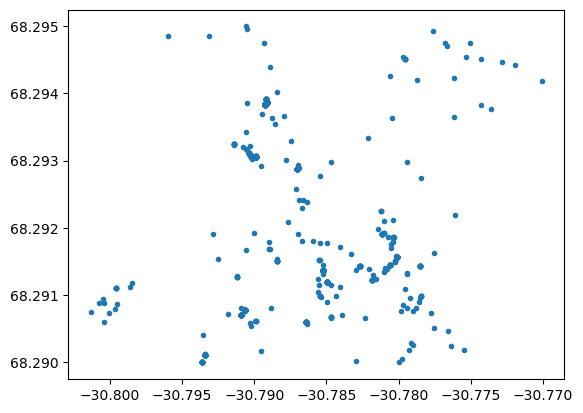

In [62]:
plt.plot(ds.lon, ds.lat, '.')

In [63]:
# Load coastlines for plotting
greenland_boundary = gpd.read_file(boundary_file)
greenland_transform = greenland_boundary.to_crs("EPSG:4326")

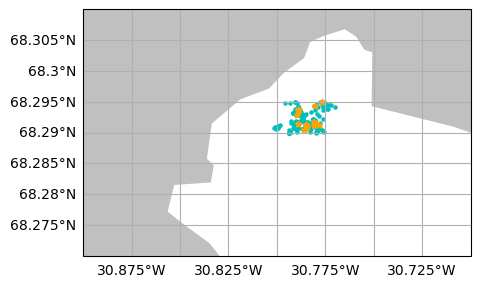

In [64]:
fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree(
    central_longitude=-31))

proj = ccrs.PlateCarree()


""" Map of area """
greenland_transform.plot(ax=ax,color='silver', transform=proj)
ax.scatter(ds.lon, ds.lat, s=5, c='c', transform=proj)
ax.scatter(df_CTD.lon.values, df_CTD.lat.values, s=20,
           c='orange', marker='*', transform=proj)
ax.set_extent(
        [-30.9, -30.7, 68.27, 68.31],
        crs=proj)
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

if section_name is not None:
    ax.set_title(section_name, fontweight='bold')

plt.show()

## Rotate u and v from VMADCP into along- and across-track velocity

In [65]:
def calculate_bearing(lat1, lon1, lat2, lon2):
    # Ensure point 1 is the southern point
    if lat1 > lat2:
        lat1, lat2 = lat2, lat1
        lon1, lon2 = lon2, lon1

    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)

    dlon = lon2 - lon1

    x = np.sin(dlon) * np.cos(lat2)
    y = (np.cos(lat1) * np.sin(lat2) -
         np.sin(lat1) * np.cos(lat2) * np.cos(dlon))

    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360

In [66]:
# rotate into along-fjord and across-fjord based on predefined angle
if section_name == None:
    bearing = 45
else:
    bearing = dict_sections[section_name]['angle']
print('Angle across fjord: ' + str(np.round(bearing, 1)) + '°')

# bearing in radians
theta = np.deg2rad(bearing)

# northerly flow is defined as positive flow along the section
along_vel = ds.u * np.sin(theta) + ds.v * np.cos(theta)
# positive across-section transport is defined to the right of the
# section direction
across_vel = ds.u * np.cos(theta) - ds.v * np.sin(theta)

# add to dataset
along_vel.attrs = {'long_name': 'Along-track velocity from VMADCP',
                   'units': 'meter second-1'}
ds['along_vel'] = along_vel
across_vel.attrs = {'long_name': 'Across-track velocity from VMADCP',
                   'units': 'meter second-1'}
ds['across_vel'] = across_vel

Angle across fjord: 45°


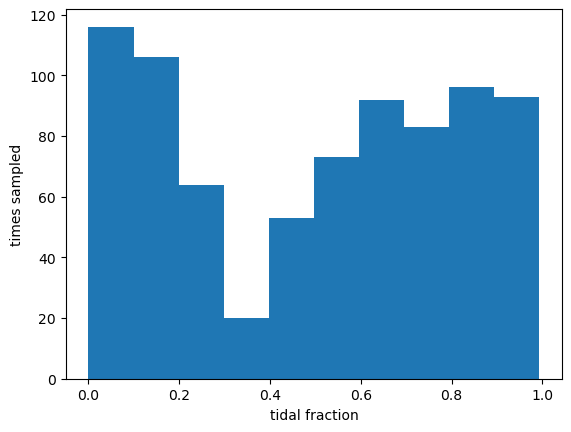

In [67]:
plt.hist(df_tide.tidefrac)
plt.xlabel('tidal fraction')
plt.ylabel('times sampled')
plt.show()

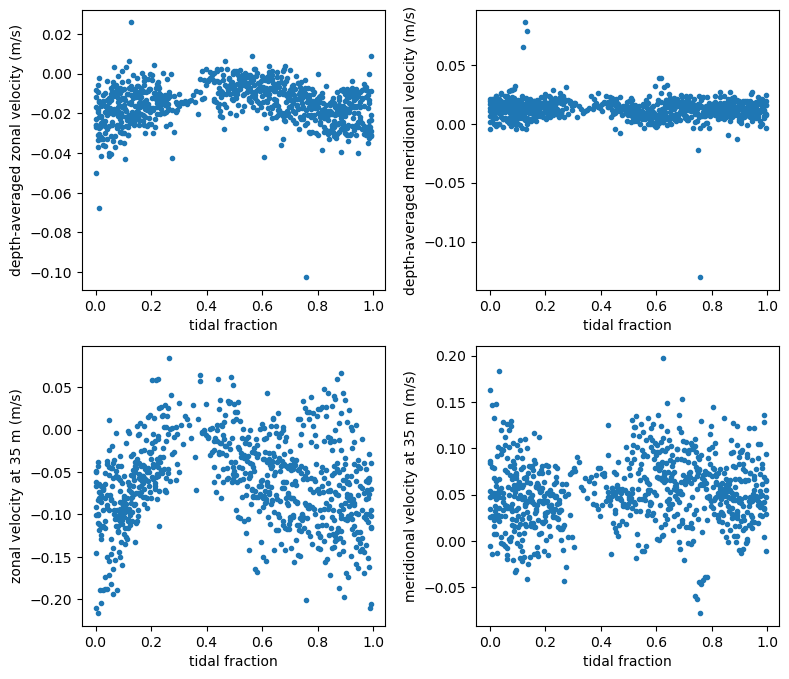

In [68]:
plt.figure(figsize=(9, 8))
plt.subplots_adjust(wspace=.3)

plt.subplot(2, 2, 1)
plt.plot(df_tide.tidefrac, ds.u.mean('depth_cell'), '.')
plt.xlabel('tidal fraction')
plt.ylabel('depth-averaged zonal velocity (m/s)')

plt.subplot(2, 2, 2)
plt.plot(df_tide.tidefrac, ds.v.mean('depth_cell'), '.')
plt.xlabel('tidal fraction')
plt.ylabel('depth-averaged meridional velocity (m/s)')

plt.subplot(2, 2, 3)
plt.plot(df_tide.tidefrac, ds.u.isel(depth_cell=5), '.')
plt.xlabel('tidal fraction')
plt.ylabel('zonal velocity at 35 m (m/s)')

plt.subplot(2, 2, 4)
plt.plot(df_tide.tidefrac, ds.v.isel(depth_cell=5), '.')
plt.xlabel('tidal fraction')
plt.ylabel('meridional velocity at 35 m (m/s)')

plt.show()

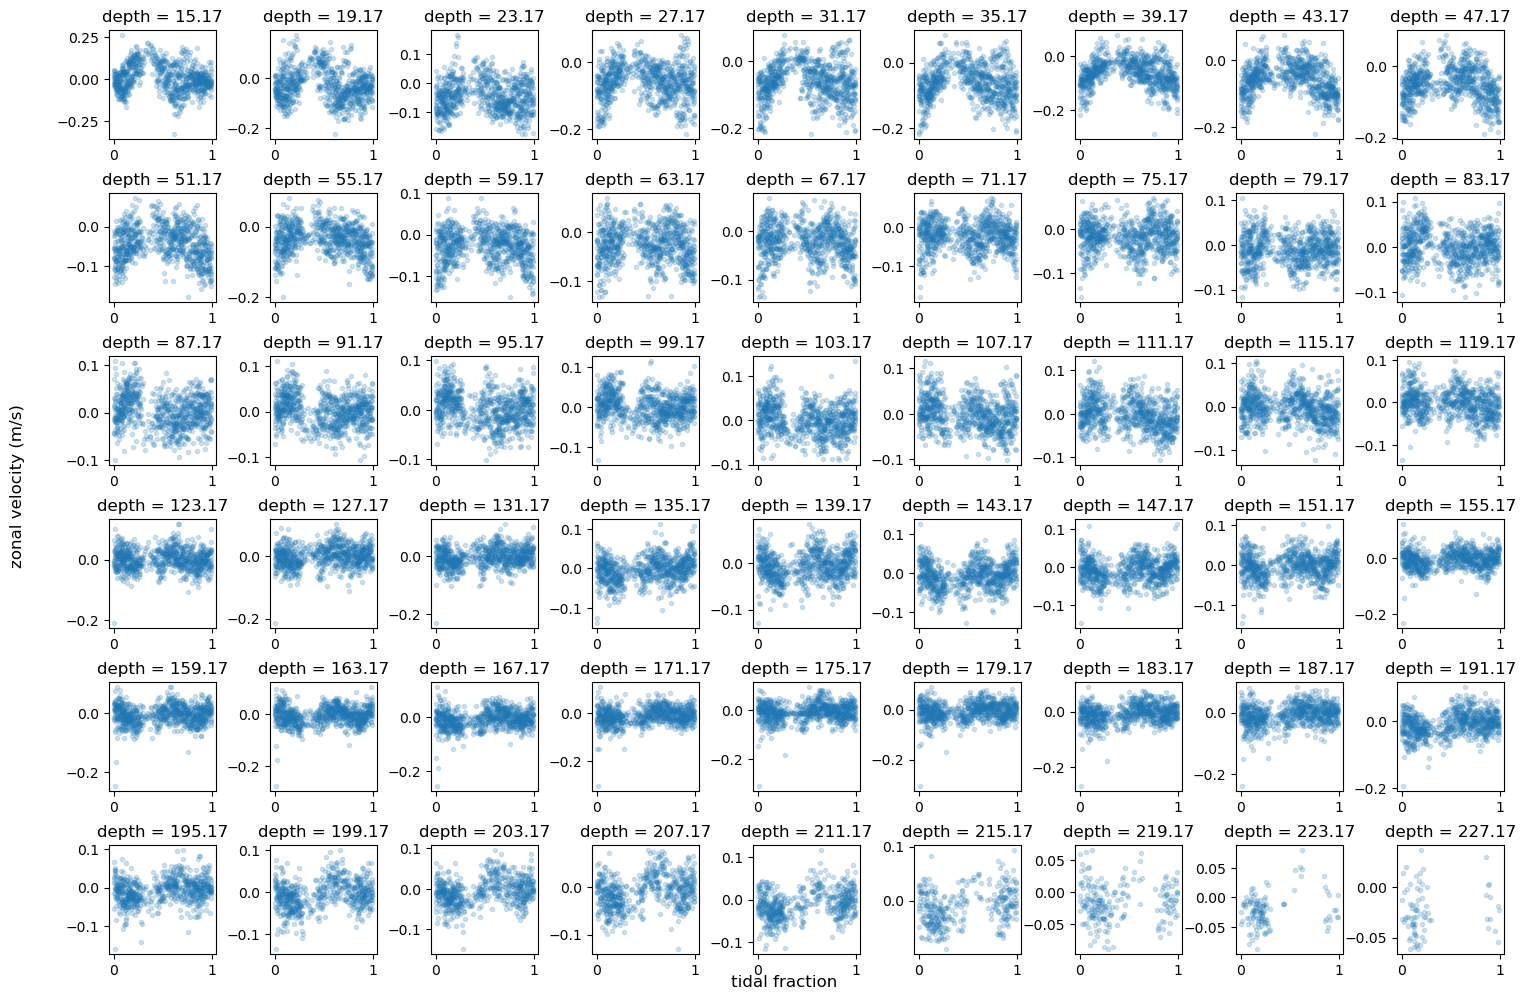

In [106]:
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=.5, wspace=.5)

for i in range(54):
    plt.subplot(6, 9, i+1)
    plt.plot(df_tide.tidefrac, ds.u.isel(depth_cell=i), '.', alpha=.2)
    
    plt.title('depth = ' + str(ds.depth[0, i].values))

fig.supxlabel('tidal fraction', y=.08)
fig.supylabel('zonal velocity (m/s)', x=.07)
plt.show()

## Plots

In [118]:
def hovmoeller_VMADCP():
    fig = plt.figure(figsize=(12, 9))
    plt.subplots_adjust(hspace=.3)
    
    var_all = [ds.u, ds.v, ds.across_vel, ds.along_vel]
    title_all = ['Zonal velocity (m s$^{-1}$)',
                 'Meridional velocity (m s$^{-1}$)',
                 'Along-fjord velocity (m s$^{-1}$)',
                 'Across-fjord velocity (m s$^{-1}$)']
    
    # Time formatting
    locator = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(locator)
    
    for i, var in enumerate(var_all):
        ax = plt.subplot(4, 1, i+1)
        v_max = np.abs(var).quantile(0.98)
        plt.pcolormesh(
            ds.time, ds.depth.mean('time'), var.transpose(),
            cmap='RdBu_r', vmin=-v_max, vmax=v_max)
        plt.ylim(max_depth_plot, 0)
        plt.colorbar(extend='both', aspect=10, pad=0.03)
        plt.title(title_all[i])
        fig.supylabel('Depth (m)', fontsize=11, x=0.07)
    
        if title_all[i][:11] == 'Along-fjord':
             ax.text(
                1.008, 0, 'into fjord   out of fjord',
                rotation=90, transform=ax.transAxes)
        elif title_all[i][:12] == 'Across-fjord':
             ax.text(
                1.008, -0.2, '"southwards"    "northwards"',
                rotation=90, transform=ax.transAxes)

        # add bar showing rising and falling tides
        ymin, ymax = ax.get_ylim()
        height = 0.05 * (ymax - ymin)  # 5% of plot height
        for j in range(len(tide_phase)):
            ax.fill_between(
                df_tide.index, ymin, ymin + height,
                where=(df_tide['phase'] == tide_phase[j]),
                color=tide_col[j], step="mid")
            if i == 0:
                if j == 0:
                    legend_handles = [
                        Patch(facecolor=tide_col[j],
                              label=(tide_phase[j] + " tide")),]
                else: 
                    legend_handles.append(
                        Patch(facecolor=tide_col[j],
                              label=(tide_phase[j])))

        # # add lines for CTD stations
        # if not df_CTD.empty:
        #     for k in range(len(df_CTD)):
        #         li = ax.axvline(df_CTD['Time'].values[k],
        #                         color='orange', label='CTD')
        #         ax.text(df_CTD['Time'].values[k], max_depth_plot-20,
        #                 '#' + str(df_CTD.CTD_cast.values[k]))
        #         if (i == 0) and (k == 0):
        #             legend_handles.append(li)
                    
        # add lines separating water masses
        for l in range(len(depth_layers)):
            ax.axhline(depth_layers[l], color='magenta', linestyle='--')

        ax.xaxis.set_major_locator(locator)
        ax.set_xticklabels([])
        ax.set_xlim(np.datetime64(t0), np.datetime64(t1))
        if i == (len(var_all)-1):
            ax.xaxis.set_major_formatter(fmt)
            ax.legend(handles=legend_handles, loc='upper center',
                      bbox_to_anchor=(0.5, -0.14), ncol=5)
        if (section_name is not None) and (i == 0):
             plt.text(-.07, 1.1, section_name[11:], fontweight='bold',
                      fontsize=12, transform=ax.transAxes)

    if save_figs:
        plt.savefig(
            path_plots + 'VMADCP_' +
            re.sub(r'_+', '_', re.sub(r'[ ./:]', '_', section_name)).rstrip('_') +
            '.png', dpi=dpi, bbox_inches="tight")

    plt.show()

In [113]:
def timeseries_VMADCP():
    fig = plt.figure(figsize=(12, 9))
    gs = fig.add_gridspec(
        nrows=4, ncols=2,
        width_ratios=[4, 1],
        height_ratios=[1, 1, 1, 1],
        hspace=0.33, wspace=0.35)
    
    var_all = [ds.u, ds.v, ds.across_vel, ds.along_vel]
    title_all = ['Zonal velocity (m s$^{-1}$)',
                 'Meridional velocity (m s$^{-1}$)',
                 'Along-fjord velocity (m s$^{-1}$)',
                 'Across-fjord velocity (m s$^{-1}$)']
    
    # Time formatting
    locator = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(locator)
    
    for i, var in enumerate(var_all):
        ax = fig.add_subplot(gs[i, 0])
        ax_tide = ax.twinx() 
        ax_tide.plot(df_tide.index, np.cos(df_tide.tidefrac*2*np.pi),
                     color='tab:purple')
        ax_tide.spines["right"].set_color("tab:purple")
        ax_tide.tick_params(axis="y", colors="tab:purple")
        ax_tide.set_ylabel('tidal fraction', color="tab:purple")
        ax.axhline(0, color='grey', linestyle='--')
        ax.plot(ds.time, var_all[i].mean('depth_cell'),
                label='depth mean')
        for j in range(len(depth_layers)):
            var = var_all[i].where(
                (ds.depth >= depth_layers[j]-4) &
                (ds.depth <= depth_layers[j]+8), drop=True)
            ax.plot(
                ds.time, var.mean('depth_cell'),
                label=str(depth_layers[j]) + ' m')
        # plt.ylim(max_depth_plot, 0)
        plt.title(title_all[i])

    
        if title_all[i][:11] == 'Along-fjord':
            ax.text(
                0.01, 0.02, 'into fjord', transform=ax.transAxes)
            ax.text(
                0.01, 0.9, 'out of fjord', transform=ax.transAxes)
        elif title_all[i][:12] == 'Across-fjord':
            ax.text(
                0.01, 0.02, '"southwards"', transform=ax.transAxes)
            ax.text(
                0.01, 0.9, '"northwards"', transform=ax.transAxes)

        ax.xaxis.set_major_locator(locator)
        ax.set_xticklabels([])
        ax.set_xlim(np.datetime64(t0), np.datetime64(t1))
        if i == (len(var_all)-1):
            ax.xaxis.set_major_formatter(fmt)
        if i == 0:
            ax.legend(loc='lower left',
                      bbox_to_anchor=(0.65, 1), ncol=5)
            if section_name is not None:
                plt.text(-.07, 1.1, section_name[11:], fontweight='bold',
                         fontsize=12, transform=ax.transAxes)


        """scatter"""
        ax = fig.add_subplot(gs[i, 1])
        ax.plot(np.cos(df_tide.tidefrac[:-1]*2*np.pi),
                var_all[i].mean('depth_cell'), '.')
        for j in range(len(depth_layers)):
            var = var_all[i].where(
                (ds.depth >= depth_layers[j]-4) &
                (ds.depth <= depth_layers[j]+8), drop=True)
            ax.plot(
                np.cos(df_tide.tidefrac[:-1]*2*np.pi), var.mean('depth_cell'), '.')
        plt.xlabel('tidal fraction')
        plt.ylabel('velocity (m s$^{-1}$)', labelpad=-3)

    if save_figs:
        plt.savefig(
            path_plots + 'VMADCP_timeseries_' +
            re.sub(r'_+', '_', re.sub(r'[ ./:]', '_', section_name)).rstrip('_') +
            '.png', dpi=dpi, bbox_inches="tight")

    plt.show()

In [114]:
def timeseries_regional_VMADCP():
    fig = plt.figure(figsize=(12, 9))
    gs = fig.add_gridspec(
        nrows=4, ncols=2,
        width_ratios=[4, 1],
        height_ratios=[1, 1, 1, 1],
        hspace=0.33, wspace=0.35)
    
    var_all = [ds.u, ds.v, ds.across_vel, ds.along_vel]
    title_all = ['Zonal velocity (m s$^{-1}$)',
                 'Meridional velocity (m s$^{-1}$)',
                 'Along-fjord velocity (m s$^{-1}$)',
                 'Across-fjord velocity (m s$^{-1}$)']
    
    # Time formatting
    locator = mdates.AutoDateLocator()
    fmt = mdates.ConciseDateFormatter(locator)
    
    for i, var in enumerate(var_all):
        ax = fig.add_subplot(gs[i, 0])
        ax_tide = ax.twinx() 
        ax_tide.plot(df_tide.index, np.cos(df_tide.tidefrac*2*np.pi),
                     color='tab:purple')
        ax_tide.spines["right"].set_color("tab:purple")
        ax_tide.tick_params(axis="y", colors="tab:purple")
        ax_tide.set_ylabel('tidal fraction', color="tab:purple")
        ax.axhline(0, color='grey', linestyle='--')
        ax.plot(ds.time, var_all[i].mean('depth_cell'),
                label='depth mean')
        for j in range(len(depth_layers)):
            var = var_all[i].where(
                (ds.depth >= depth_layers[j]-4) &
                (ds.depth <= depth_layers[j]+8), drop=True)
            ax.plot(
                ds.time, var.mean('depth_cell'),
                label=str(depth_layers[j]) + ' m')
        # plt.ylim(max_depth_plot, 0)
        plt.title(title_all[i])

    
        if title_all[i][:11] == 'Along-fjord':
            ax.text(
                0.01, 0.02, 'into fjord', transform=ax.transAxes)
            ax.text(
                0.01, 0.9, 'out of fjord', transform=ax.transAxes)
        elif title_all[i][:12] == 'Across-fjord':
            ax.text(
                0.01, 0.02, '"southwards"', transform=ax.transAxes)
            ax.text(
                0.01, 0.9, '"northwards"', transform=ax.transAxes)

        ax.xaxis.set_major_locator(locator)
        ax.set_xticklabels([])
        ax.set_xlim(np.datetime64(t0), np.datetime64(t1))
        if i == (len(var_all)-1):
            ax.xaxis.set_major_formatter(fmt)
        if i == 0:
            ax.legend(loc='lower left',
                      bbox_to_anchor=(0.65, 1), ncol=5)
            if section_name is not None:
                plt.text(-.07, 1.1, section_name[11:], fontweight='bold',
                         fontsize=12, transform=ax.transAxes)


        # """scatter"""
        # ax = fig.add_subplot(gs[i, 1])
        # ax.plot(np.cos(df_tide.tidefrac[:-1]*2*np.pi),
        #         var_all[i].mean('depth_cell'), '.')
        # for j in range(len(depth_layers)):
        #     var = var_all[i].where(
        #         (ds.depth >= depth_layers[j]-4) &
        #         (ds.depth <= depth_layers[j]+8), drop=True)
        #     ax.plot(
        #         np.cos(df_tide.tidefrac[:-1]*2*np.pi), var.mean('depth_cell'), '.')
        # plt.xlabel('tidal fraction')
        # plt.ylabel('velocity (m s$^{-1}$)', labelpad=-3)

    if save_figs:
        plt.savefig(
            path_plots + 'VMADCP_timeseries_regional_' +
            re.sub(r'_+', '_', re.sub(r'[ ./:]', '_', section_name)).rstrip('_') +
            '.png', dpi=dpi, bbox_inches="tight")

    plt.show()

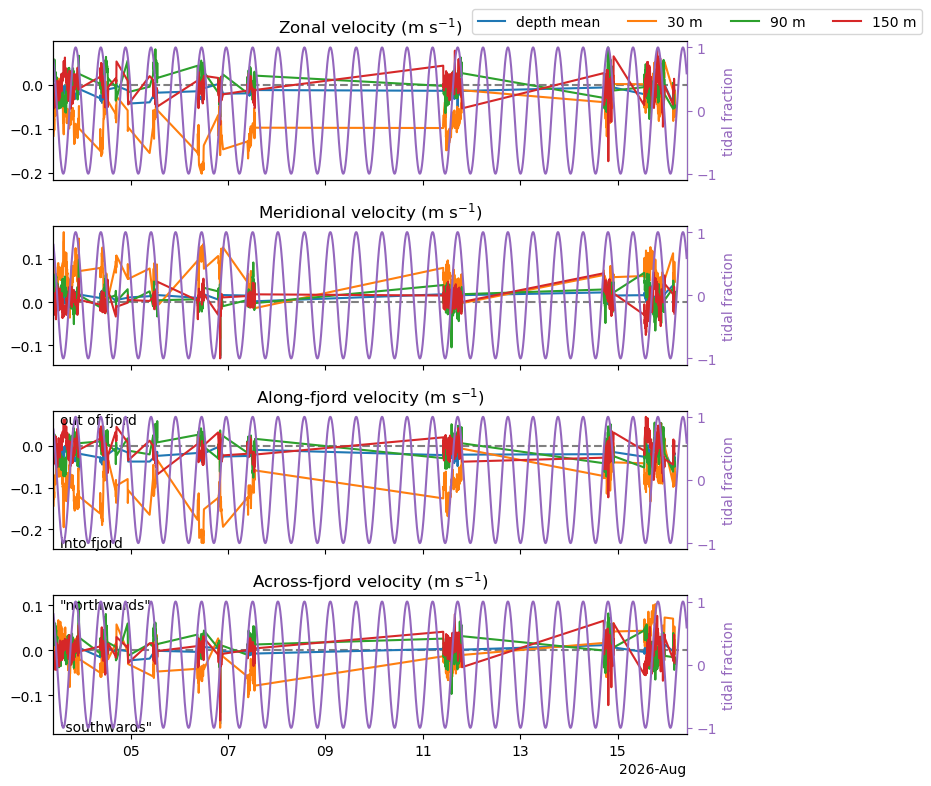

In [116]:
timeseries_regional_VMADCP()

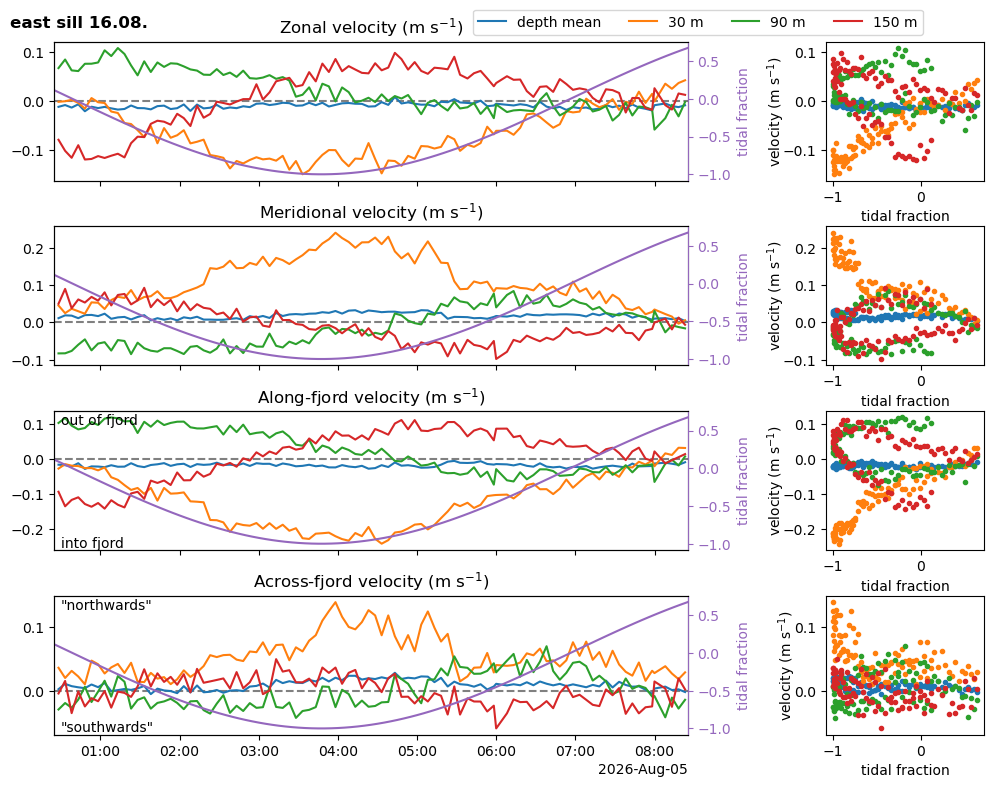

In [68]:
timeseries_VMADCP()

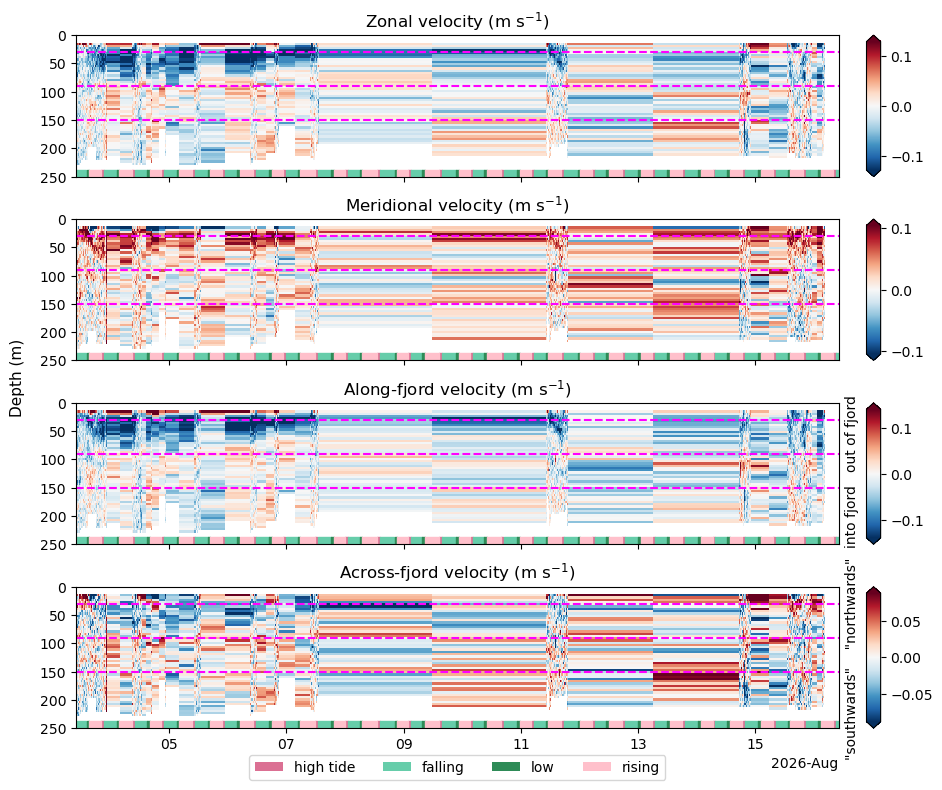

In [119]:
hovmoeller_VMADCP()